In [13]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils._raised_cosine_basis import makeRaisedCosBasis
import pandas as pd
# from utils.load_matlab import load_mat_v73, flatten_cell
import utils
from utils import *
from scipy.ndimage import gaussian_filter1d
import seaborn as sns
sns.set_context("poster")
plt.rcParams["figure.dpi"] = 100
# !git pull

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/NUIN/CBEM_pytorch
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## Work in several cells

Available cell types: ['OFF transient alpha' 'ON alpha' 'ON delayed' 'OFF sustained alpha']
Number of cells of celltype ON alpha:  3
######################################################################
Processing cell: 032825Bc6. 
train: (9, 100000) (9, 100000) mean rate (Hz): 2.077777777777778
test : (6, 100000) (6, 100000) mean rate (Hz): 2.283333333333333


/content/drive/MyDrive/NUIN/CBEM_pytorch/utils/data_preprocessing.py:104: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


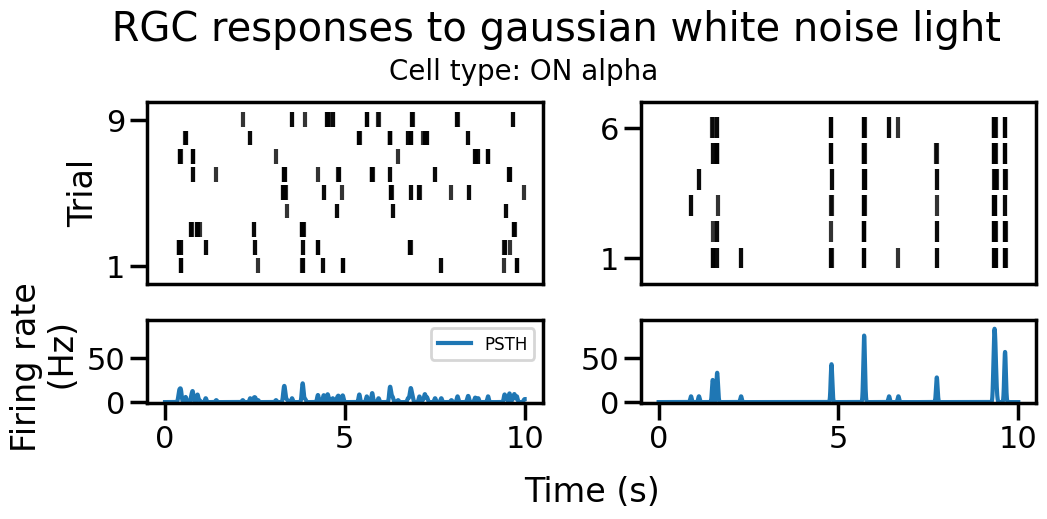

Design matrix shapes: torch.Size([9, 100000, 11]) torch.Size([6, 100000, 11])
------------------------------
Training linear cbem
[train] Initialized B_cond with zeros with shape (11, 1)
model device: cuda:0
step     1 | loss 198.632 | data 198.632 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 1.403 Hz
step   200 | loss 151.989 | data 151.989 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 2.168 Hz
step   400 | loss 151.827 | data 151.827 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 2.141 Hz
------------------------------
Training full CBEM
[train] Using existing B_cond with shape (11, 2)
model device: cuda:0
step     1 | loss 257.713 | data 249.094 | pen_w 8.619 | pen_sm 1.335875e-06 | mean rate 14.173 Hz
step   100 | loss 159.291 | data 155.742 | pen_w 3.549 | pen_sm 3.902106e-08 | mean rate 2.336 Hz
step   200 | loss 157.614 | data 154.206 | pen_w 3.408 | pen_sm 2.162656e-07 | mean rate 2.207 Hz
step   300 | loss 156.996 | data 153.519 | pen_w 3.476 | pen_sm 3.294925e-07 | mean

/content/drive/MyDrive/NUIN/CBEM_pytorch/utils/data_preprocessing.py:104: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


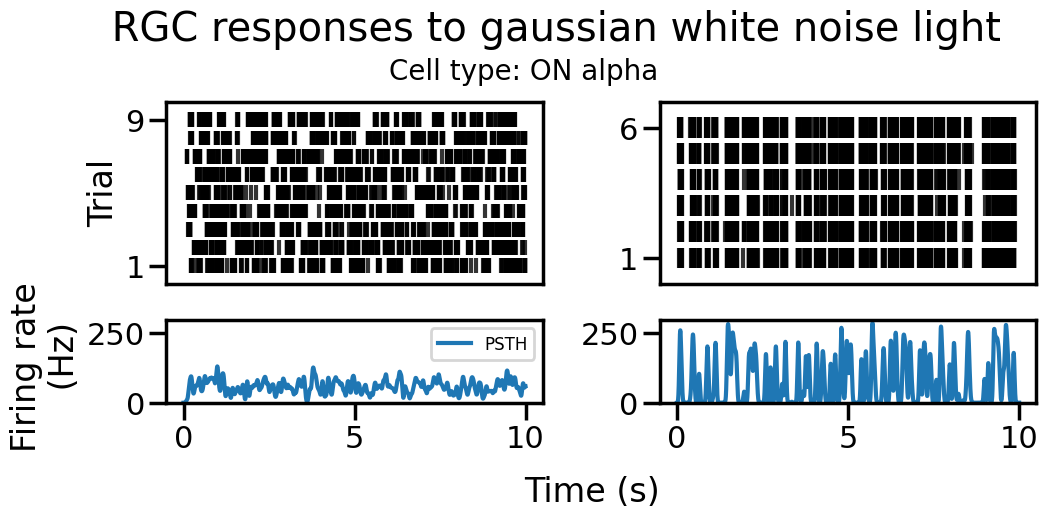

Design matrix shapes: torch.Size([9, 100000, 11]) torch.Size([6, 100000, 11])
------------------------------
Training linear cbem
[train] Initialized B_cond with zeros with shape (11, 1)
model device: cuda:0
step     1 | loss 5140.520 | data 5140.520 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 1.415 Hz
step   200 | loss 3153.437 | data 3153.437 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 59.148 Hz
step   400 | loss 3153.426 | data 3153.426 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 59.172 Hz
------------------------------
Training full CBEM
[train] Using existing B_cond with shape (11, 2)
model device: cuda:0
step     1 | loss 3689.956 | data 3681.114 | pen_w 8.842 | pen_sm 2.862825e-08 | mean rate 15.718 Hz
step   100 | loss 3192.283 | data 3180.684 | pen_w 11.599 | pen_sm 5.692811e-08 | mean rate 53.427 Hz
step   200 | loss 3141.451 | data 3132.051 | pen_w 9.400 | pen_sm 6.112003e-07 | mean rate 57.174 Hz
step   300 | loss 3138.799 | data 3129.514 | pen_w 9.285 | pen_sm 

/content/drive/MyDrive/NUIN/CBEM_pytorch/utils/data_preprocessing.py:104: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


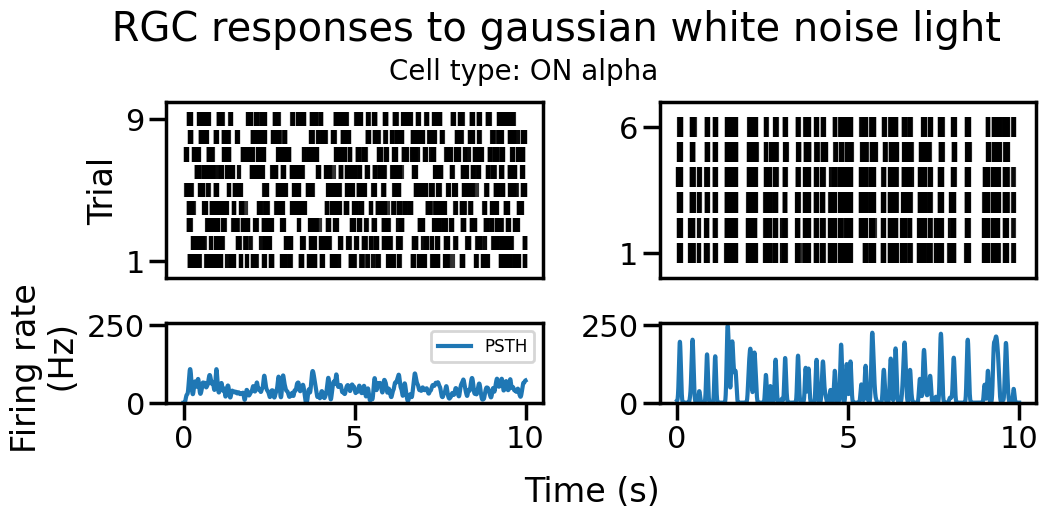

Design matrix shapes: torch.Size([9, 100000, 11]) torch.Size([6, 100000, 11])
------------------------------
Training linear cbem
[train] Initialized B_cond with zeros with shape (11, 1)
model device: cuda:0
step     1 | loss 3953.556 | data 3953.556 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 1.411 Hz
step   200 | loss 2507.008 | data 2507.008 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 45.312 Hz
step   400 | loss 2506.996 | data 2506.996 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 45.293 Hz
------------------------------
Training full CBEM
[train] Using existing B_cond with shape (11, 2)
model device: cuda:0
step     1 | loss 2838.249 | data 2830.530 | pen_w 7.719 | pen_sm 1.220184e-07 | mean rate 13.610 Hz
step   100 | loss 2508.273 | data 2494.399 | pen_w 13.874 | pen_sm 8.873892e-08 | mean rate 41.233 Hz
step   200 | loss 2494.468 | data 2483.826 | pen_w 10.642 | pen_sm 6.535743e-08 | mean rate 44.101 Hz
step   300 | loss 2494.382 | data 2483.858 | pen_w 10.524 | pen_s

In [14]:
from pathlib import Path
from sklearn.metrics import r2_score

data = pd.read_hdf("Data/TemporalNoise1f_v2.h5", key='data')
frame_rate = 60
dt = 1e-4
fd = 1
dt_stim = 1 / frame_rate

### stim basis params
nLinearRFs = 10  # number of stimulus basis functions
numShortSHFilts = 5  # each is 0.4ms long - used for refractory period
nSHfilters = 7 + numShortSHFilts

nInh = 1
nExc = 1

RFstart = 2e-3
RFend = 150e-3
b = 0.02

# Training/eval config
plot_each_cell = True
save_plots = True
linear_cfg = {
    "lr": 1e-1,
    "conductance_penalty": None,
    "n_steps": 400,
    "print_every": 200,
    "clip_grad_norm": 1.0,
    "window_size": None,
    "seed": 0,
}
full_penalty = (1.0, 0.2, 0.1, 3.0)
full_cfg = {
    "lr": 1e-1,
    "n_steps": 2000,
    "print_every": 100,
    "clip_grad_norm": 1.0,
    "window_size": None,
    "seed": 0,
}

def _state_dict_to_cpu(model):
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}

print(f"Available cell types: {data['cell_type'].unique()}")
# cell_type   = "OFF transient alpha"
# cell_type   = "OFF sustained alpha"
cell_type     = 'ON alpha'

cell_type_slug = (
    str(cell_type).strip().lower().replace(" ", "_").replace("/", "_").replace("-", "_")
)
out_root = Path("Results") / "multi_cell" / cell_type_slug
ckpt_dir = out_root / "checkpoints"
metrics_dir = out_root / "metrics"
fig_dir = out_root / "figures"
for p in (ckpt_dir, metrics_dir, fig_dir):
    p.mkdir(parents=True, exist_ok=True)
summary_path = out_root / "summary.csv"

results_by_cell = {}
if summary_path.exists():
    _prev = pd.read_csv(summary_path)
    for _row in _prev.to_dict(orient="records"):
        results_by_cell[str(_row["cell_name"])] = _row

ctype_df = data.query(f"cell_type == '{cell_type}' and beta == 0").copy().reset_index(drop=True)
print(f"Number of cells of celltype {cell_type}: ", ctype_df["cell_name"].nunique())

# Shared basis only needs to be built once
_, B_orth, _ = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
B_orth_t = torch.as_tensor(B_orth, dtype=torch.float64, device=device)
sigma = max(1, int(0.02 / dt))

for cell_name in ctype_df["cell_name"].unique():
    cell_name = str(cell_name)
    print("#" * 70)
    print(f"Processing cell: {cell_name}. ")

    cell_df = ctype_df.query(f"cell_name == '{cell_name}'").reset_index(drop=True)
    quadrant = cell_df["quadrant"][0]
    spot_size = cell_df["aperture"][0]

    # -------- training & test sets (once per cell) --------
    stim_mat = np.stack(cell_df.loc[cell_df.noise_seed != 1, "stimulus"])
    stim_rs = np.stack(cell_df.loc[cell_df.noise_seed == 1, "stimulus"])
    spk_t = np.array(cell_df.loc[cell_df.noise_seed != 1, "spike_times"].tolist(), dtype=object)
    spktimes_rs = np.array(cell_df.loc[cell_df.noise_seed == 1, "spike_times"].tolist(), dtype=object)

    trial_dur_s = stim_mat.shape[1] * dt_stim
    T_bins = int(round(trial_dur_s / dt))
    bin_edges_s = np.arange(T_bins + 1) * dt

    stimulus, spk_train = preprocess_split(
        stim_mat,
        spk_t,
        presamples=None,
        postsamples=None,
        n_trials=len(spk_t),
        T_cell_full=T_bins,
        dt_stim=dt_stim,
        dt=dt,
        bin_edges_s=bin_edges_s,
    )
    stimulus_test, spk_test = preprocess_split(
        stim_rs,
        spktimes_rs,
        presamples=None,
        postsamples=None,
        n_trials=len(spktimes_rs),
        T_cell_full=T_bins,
        dt_stim=dt_stim,
        dt=dt,
        bin_edges_s=bin_edges_s,
    )

    mean_rate_train_hz = float(spk_train.mean() / dt)
    mean_rate_test_hz = float(spk_test.mean() / dt)
    print("train:", stimulus.shape, spk_train.shape, "mean rate (Hz):", mean_rate_train_hz)
    print("test :", stimulus_test.shape, spk_test.shape, "mean rate (Hz):", mean_rate_test_hz)

    spk_idx_trials = [
        torch.as_tensor(np.where(spk_train[b] > 0)[0], device=device, dtype=torch.long)
        for b in range(spk_train.shape[0])
    ]
    spk_idx_test = [
        torch.as_tensor(np.where(spk_test[b] > 0)[0], device=device, dtype=torch.long)
        for b in range(spk_test.shape[0])
    ]

    if plot_each_cell:
        spk_t_s_test = [idx.detach().cpu().numpy() * dt for idx in spk_idx_test]
        spk_t_s_train = [idx.detach().cpu().numpy() * dt for idx in spk_idx_trials]
        B_test, T_test = spk_test.shape
        B_tr, _ = spk_train.shape
        psth_test_tmp = gaussian_filter1d(spk_test.mean(axis=0) / dt, sigma=sigma)
        psth_train_tmp = gaussian_filter1d(spk_train.mean(axis=0) / dt, sigma=sigma)
        fig = plot_responses(
            spk_t_s_train,
            spk_t_s_test,
            psth_test_tmp,
            psth_train_tmp,
            cell_type,
            dt,
            B_test,
            B_tr,
            T_test,
        )
        if save_plots:
            fig.savefig(fig_dir / f"{cell_name}_responses.png", dpi=150, bbox_inches="tight")
            plt.close(fig)

    # -------- Design matrices --------
    stimulus_t = torch.as_tensor(stimulus, dtype=torch.float64, device=device)
    stimulus_test_t = torch.as_tensor(stimulus_test, dtype=torch.float64, device=device)

    X_full = torch.stack(
        [
            convolveStimulusWithBasis_torch(stimulus_t[b], B_orth_t, add_ones=True)
            for b in range(stimulus_t.shape[0])
        ],
        dim=0,
    )
    X_test = torch.stack(
        [
            convolveStimulusWithBasis_torch(stimulus_test_t[b], B_orth_t, add_ones=True)
            for b in range(stimulus_test_t.shape[0])
        ],
        dim=0,
    )
    print("Design matrix shapes:", X_full.shape, X_test.shape)

    # -------- Train linear CBEM --------
    print("-" * 30)
    print("Training linear cbem")
    linmodel = CBEM_linear(binsize_s=dt).to(device)
    cbem_lin, (steps_hist_lin, loss_hist_lin) = train_cbem_trials(
        linmodel,
        X_cond=X_full,
        basis_matrix=B_orth_t,
        spkTimes_bins=spk_idx_trials,
        **linear_cfg,
    )
    B_cond_lin = cbem_lin.B_cond.detach().cpu()
    w_lin = B_cond_lin[:, 0].to(device)

    # -------- Initialize + train full CBEM --------
    print("-" * 30)
    print("Training full CBEM")
    model = CBEM_trials(binsize_s=dt).to(device)
    with torch.no_grad():
        _ = model(X_full[:, :1, :])
        model.B_cond[:, 0].copy_(w_lin)
        model.B_cond[:, 1].copy_(-w_lin)
        # model.B_cond[-1, :].fill_(5.0)
        model.B_cond[-1, :].fill_(1.0) #different for ON alphas
        
    trained, (steps_hist_full, loss_hist_full) = train_cbem_trials(
        model,
        X_cond=X_full,
        basis_matrix=B_orth_t,
        spkTimes_bins=spk_idx_trials,
        conductance_penalty=full_penalty,
        **full_cfg,
    )

    # -------- Eval on held-out test --------
    with torch.no_grad():
        rate_test_lin_bt, _ = cbem_lin(X_test)
        rate_test_full_bt, _ = trained(X_test)

    psth_test_hz = gaussian_filter1d(spk_test.mean(axis=0) / dt, sigma=sigma)
    rate_lin_hz = gaussian_filter1d(rate_test_lin_bt.mean(dim=0).detach().cpu().numpy(), sigma=sigma)
    rate_full_hz = gaussian_filter1d(rate_test_full_bt.mean(dim=0).detach().cpu().numpy(), sigma=sigma)

    r2_lin = float(r2_score(psth_test_hz, rate_lin_hz))
    r2_full = float(r2_score(psth_test_hz, rate_full_hz))

    B_cond_full = trained.B_cond.detach().cpu()
    filters = B_orth_t.detach().cpu() @ B_cond_full[:-1, :]
    K_exc = filters[:, 0].numpy()
    K_inh = filters[:, 1].numpy()

    final_train_loss_lin = float(
        cbem_penalized_nll_trials(
            cbem_lin,
            X_btd=X_full,
            basis_matrix=B_orth_t,
            spk_bins_list=spk_idx_trials,
            window=None,
            conductance_penalty=None,
        )
        .detach()
        .cpu()
    )
    final_train_loss_full = float(
        cbem_penalized_nll_trials(
            trained,
            X_btd=X_full,
            basis_matrix=B_orth_t,
            spk_bins_list=spk_idx_trials,
            window=None,
            conductance_penalty=full_penalty,
        )
        .detach()
        .cpu()
    )

    # -------- Save per-cell artifacts --------
    ckpt_path = ckpt_dir / f"{cell_name}.pt"
    metrics_path = metrics_dir / f"{cell_name}.npz"

    ckpt = {
        "cell_name": cell_name,
        "cell_type": cell_type,
        "quadrant": quadrant,
        "spot_size": spot_size,
        "dt": float(dt),
        "dt_stim": float(dt_stim),
        "sigma_bins": int(sigma),
        "n_train_trials": int(spk_train.shape[0]),
        "n_test_trials": int(spk_test.shape[0]),
        "train_mean_rate_hz": mean_rate_train_hz,
        "test_mean_rate_hz": mean_rate_test_hz,
        "basis": {
            "nLinearRFs": nLinearRFs,
            "RFstart": RFstart,
            "RFend": RFend,
            "b": b,
            "B_orth": B_orth_t.detach().cpu(),
        },
        "linear_cfg": linear_cfg,
        "full_cfg": {**full_cfg, "conductance_penalty": full_penalty},
        "linear": {
            "state_dict": _state_dict_to_cpu(cbem_lin),
            "B_cond": B_cond_lin,
            "steps_hist": steps_hist_lin,
            "loss_hist": loss_hist_lin,
            "final_train_loss": final_train_loss_lin,
        },
        "full": {
            "state_dict": _state_dict_to_cpu(trained),
            "B_cond": B_cond_full,
            "steps_hist": steps_hist_full,
            "loss_hist": loss_hist_full,
            "final_train_loss": final_train_loss_full,
        },
        "eval": {
            "r2_lin": r2_lin,
            "r2_full": r2_full,
        },
    }
    torch.save(ckpt, ckpt_path)

    np.savez(
        metrics_path,
        dt=np.asarray(dt, dtype=np.float64),
        r2_cbem_lin=np.asarray(r2_lin, dtype=np.float64),
        r2_cbem_full=np.asarray(r2_full, dtype=np.float64),
        K_exc=K_exc,
        K_inh=K_inh,
        rate_lin_hz=rate_lin_hz,
        rate_full_hz=rate_full_hz,
        psth_test_hz=psth_test_hz,
        final_train_loss_lin=np.asarray(final_train_loss_lin, dtype=np.float64),
        final_train_loss_full=np.asarray(final_train_loss_full, dtype=np.float64),
        steps_hist_lin=np.asarray(steps_hist_lin),
        loss_hist_lin=np.asarray(loss_hist_lin),
        steps_hist_full=np.asarray(steps_hist_full),
        loss_hist_full=np.asarray(loss_hist_full),
    )

    # -------- Summary row (written every iteration) --------
    summary_row = {
        "cell_name": cell_name,
        "cell_type": cell_type,
        "quadrant": quadrant,
        "aperture": spot_size,
        "n_train_trials": int(spk_train.shape[0]),
        "n_test_trials": int(spk_test.shape[0]),
        "train_mean_rate_hz": mean_rate_train_hz,
        "test_mean_rate_hz": mean_rate_test_hz,
        "r2_cbem_lin": r2_lin,
        "r2_cbem_full": r2_full,
        "final_train_loss_lin": final_train_loss_lin,
        "final_train_loss_full": final_train_loss_full,
        "checkpoint_path": str(ckpt_path),
        "metrics_path": str(metrics_path),
    }
    results_by_cell[cell_name] = summary_row

    summary_df = pd.DataFrame(list(results_by_cell.values())).sort_values("cell_name")
    summary_df.to_csv(summary_path, index=False)

    print(
        f"Saved {cell_name}: r2_lin={r2_lin:.4f}, r2_full={r2_full:.4f} | "
        f"ckpt={ckpt_path.name}, metrics={metrics_path.name}"
    )

print("=" * 70)
print(f"Done. Summary saved to: {summary_path}")

